# Practical Test — Machine Learning
**Time:** 1.5 Hours &nbsp;|&nbsp; **Total Marks:** 40

**Instructions:** Run the first cell to load your dataset. Do NOT modify it. Answer each question in the cell provided below it.

---

In [28]:
# ============================================================
#  DO NOT MODIFY THIS CELL
# ============================================================
import numpy as np
import pandas as pd
np.random.seed(101)

n = 300
dept       = np.random.choice(['HR', 'IT', 'Finance', 'Sales'], n, p=[0.2, 0.35, 0.25, 0.2])
edu        = np.random.choice(['Bachelor', 'Master', 'PhD'], n, p=[0.5, 0.35, 0.15])
age        = np.random.randint(22, 60, n)
exp        = np.clip(age - 22 + np.random.randint(-3, 4, n), 0, 35)
perf       = np.round(np.random.uniform(1.5, 5.0, n), 1)
train_hrs  = np.random.randint(5, 80, n)

edu_map    = {'Bachelor': 0, 'Master': 1, 'PhD': 2}
dept_map   = {'HR': 0, 'IT': 3, 'Finance': 2, 'Sales': 1}
salary = (
    25000
    + exp * 1800
    + perf * 4000
    + np.vectorize(edu_map.get)(edu) * 7000
    + np.vectorize(dept_map.get)(dept) * 3000
    + np.random.normal(0, 5000, n)
).round(-2)

promo_score = 0.4*perf + 0.02*exp + 0.01*train_hrs + np.vectorize(edu_map.get)(edu)*0.3
promoted    = (promo_score + np.random.normal(0, 0.4, n) > 2.8).astype(int)

# Inject missing values
for col_idx in [2, 5]:
    mask = np.random.choice(n, 18, replace=False)
    if col_idx == 2:
        age = age.astype(float)
        age[mask] = np.nan
    else:
        train_hrs = train_hrs.astype(float)
        train_hrs[mask] = np.nan

df = pd.DataFrame({
    'Age':              age,
    'YearsExperience':  exp,
    'Department':       dept,
    'EducationLevel':   edu,
    'PerformanceScore': perf,
    'TrainingHours':    train_hrs,
    'Salary':           salary,
    'Promoted':         promoted
})

print('Dataset ready! Shape:', df.shape)

Dataset ready! Shape: (300, 8)


---
### Q1 &nbsp;[5 marks]
Display the **first 5 rows**, **shape**, **column data types**, and the **number of missing values** in each column.

In [29]:
df.to_csv('../data/employee_data.csv', index=False)
print('Saved!')

Saved!


In [30]:
# Your answer here
print(df.shape)
df.head()

(300, 8)


,Age,YearsExperience,Department,EducationLevel,PerformanceScore,TrainingHours,Salary,Promoted
0,28.0,3,IT,Master,2.9,39.0,61300.0,0
1,34.0,12,Finance,Bachelor,4.3,76.0,80200.0,0
2,53.0,29,HR,Bachelor,1.8,69.0,79100.0,0
3,52.0,27,HR,Master,2.7,49.0,89900.0,0
4,26.0,4,Finance,Bachelor,4.5,19.0,65500.0,0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               282 non-null    float64
 1   YearsExperience   300 non-null    int64  
 2   Department        300 non-null    str    
 3   EducationLevel    300 non-null    str    
 4   PerformanceScore  300 non-null    float64
 5   TrainingHours     282 non-null    float64
 6   Salary            300 non-null    float64
 7   Promoted          300 non-null    int64  
dtypes: float64(4), int64(2), str(2)
memory usage: 18.9 KB


---
### Q2 &nbsp;[5 marks]
- Fill missing values in **Age** and **TrainingHours** with their **median**.
- Encode **Department** and **EducationLevel** into numbers so they can be used in a model.
- Confirm no missing values remain.

In [32]:
# Your answer here
df.isna().sum()
age_median = df['Age'].median()
hours_median = df['TrainingHours'].median()
print(f'Age median: {age_median}')
print(f'Training Hours median: {hours_median}')

Age median: 40.0
Training Hours median: 40.0


In [33]:
df['Age'] = df['Age'].fillna(age_median)
df['TrainingHours'] = df['TrainingHours'].fillna(hours_median)
df.isnull().sum()

Age                 0
YearsExperience     0
Department          0
EducationLevel      0
PerformanceScore    0
TrainingHours       0
Salary              0
Promoted            0
dtype: int64

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Department'] = le.fit_transform(df['Department'])
df['EducationLevel'] = le.fit_transform(df['EducationLevel'])
df.head()

,Age,YearsExperience,Department,EducationLevel,PerformanceScore,TrainingHours,Salary,Promoted
0,28.0,3,2,1,2.9,39.0,61300.0,0
1,34.0,12,0,0,4.3,76.0,80200.0,0
2,53.0,29,1,0,1.8,69.0,79100.0,0
3,52.0,27,1,1,2.7,49.0,89900.0,0
4,26.0,4,0,0,4.5,19.0,65500.0,0


---
### Q3 &nbsp;[5 marks]
Create **3 plots**:
1. Histogram of **Salary**
2. Correlation heatmap of all numeric columns
3. Bar chart showing **average Salary per Department** (use original string column before encoding)

(array([ 4.,  4.,  6., 11., 16., 16., 21., 23., 18., 28., 24., 31., 19.,
        17., 23., 15., 12.,  7.,  3.,  2.]),
 array([ 32800.,  37665.,  42530.,  47395.,  52260.,  57125.,  61990.,
         66855.,  71720.,  76585.,  81450.,  86315.,  91180.,  96045.,
        100910., 105775., 110640., 115505., 120370., 125235., 130100.]),
 <BarContainer object of 20 artists>)

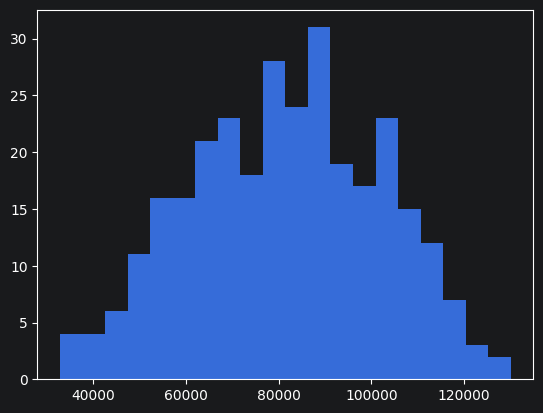

In [35]:
# Your answer here
import matplotlib.pyplot as plt
plt.hist(x=df['Salary'],bins=20)

<Axes: >

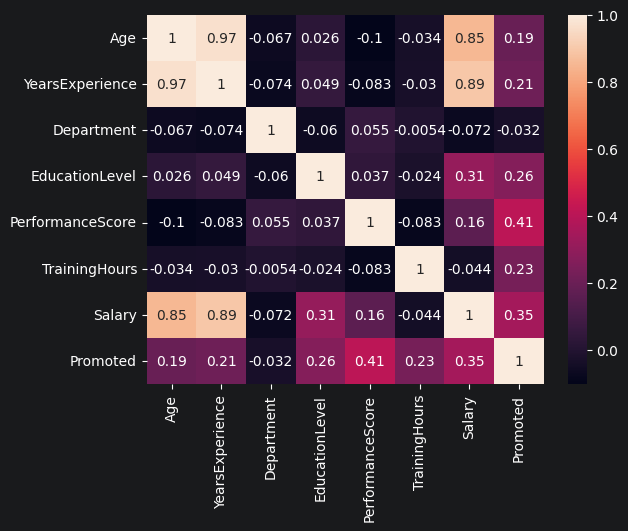

In [36]:
from seaborn import heatmap
heatmap(df.corr(),annot=True)

<BarContainer object of 300 artists>

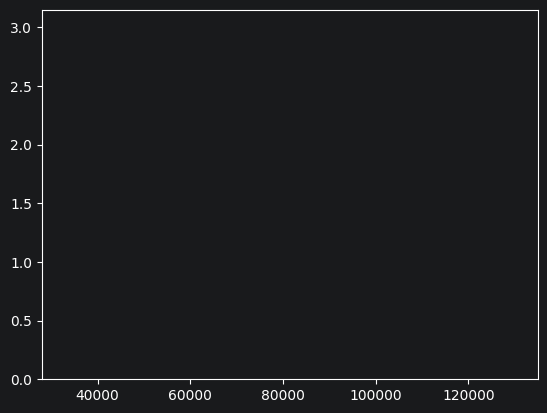

In [37]:
plt.bar(x=df['Salary'],height=df['Department'])

---
### Q4 &nbsp;[10 marks] — Linear Regression
Predict **Salary** using all other columns except `Promoted`.
- Split data: **80% train, 20% test** (`random_state=42`)
- Train a **Linear Regression** model
- Print the **R² score** and **RMSE** on the test set
- Plot **Actual vs Predicted** salary as a scatter plot

In [38]:
# Your answer here
X=df.drop(['Salary'],axis=1)
X.head()

,Age,YearsExperience,Department,EducationLevel,PerformanceScore,TrainingHours,Promoted
0,28.0,3,2,1,2.9,39.0,0
1,34.0,12,0,0,4.3,76.0,0
2,53.0,29,1,0,1.8,69.0,0
3,52.0,27,1,1,2.7,49.0,0
4,26.0,4,0,0,4.5,19.0,0


---
### Q5 &nbsp;[10 marks] — Random Forest Classification
Predict whether an employee will be **Promoted** using all other columns except `Salary`.
- Split data: **80% train, 20% test** (`random_state=42`)
- Train a **Random Forest Classifier** (`n_estimators=100`)
- Print **Accuracy** and **Classification Report**
- Show the **Confusion Matrix** as a heatmap

In [39]:
# Your answer here


---
### Q6 &nbsp;[5 marks] — Feature Importance
Using the Random Forest model from Q5, plot the **feature importances** as a horizontal bar chart.
Which feature is the most important for predicting promotion? **Write your answer as a comment.**

In [40]:
# Your answer here

# Most important feature: 
